In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.ndimage import gaussian_filter , gaussian_filter1d

from matplotlib.colors import Normalize
import umap
from sklearn.decomposition import PCA


/Users/sara/miniconda3/envs/grid/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Light dark data set, Waaga et. al. 2022

In [3]:
def opening_files(file_name, lighting = 'light'):
        dir_ = 'moser_dl'
        file_path =  os.path.join(dir_ , file_name)
        data = np.load(file_path , allow_pickle=True).item()
        if lighting=='light':
            section = 1
        elif lighting=='dark':
            section = 0

        # light = 1
        # dark = 0
        st = data["task"][section]["spike_timestamp"]
        cid = data["task"][section]["spike_cluster_id"]

        open_field_light_1 = data['task'][section]

        neurons_id = np.unique(open_field_light_1 ["spike_cluster_id"])
        module_id = data['module_id']

        this_rat = {}
        t = data['task'][section]['tracking']['t']
        t0 = t[0]

        this_rat['t'] = t-t[0]
        this_rat['x'] = data['task'][section]['tracking']['x']
        this_rat['y'] = data['task'][section]['tracking']['y']
        this_rat['z'] = data['task'][section]['tracking']['z']
        this_rat['hd'] = data['task'][section]['tracking']['hd']
        this_rat['grid_mod1'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 1]}
        this_rat['grid_mod2'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 2]}
        this_rat['grid_mod3'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 3]}
        dt = np.mean( this_rat['t'][1:] - this_rat['t'][:-1])
        speed = np.sqrt( ( this_rat['x'][1:] - this_rat['x'][:-1] )**2 + ( this_rat['y'][1:] - this_rat['y'][:-1] ) **2 )  / dt
        this_rat['speed'] = np.append([0] , speed) #assuming the motion is starting at speed 0

        return this_rat
# rat2_dark = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy' , 'dark')

# rat1 = opening_files('moserlab_waaga_25843_2019-09-13_22-54-22_v1.npy' , 'light')
# rat2 = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy' , 'light')
# rat3 = opening_files('moserlab_waaga_26018_2019-12-14_16-03-44_v1.npy' , 'light')
# rat4 = opening_files('moserlab_waaga_26718_2020-09-16_17-23-51_v1.npy' , 'light')
# rat5 = opening_files('moserlab_waaga_26820_2020-11-05_11-03-13_v1.npy' , 'light')

# rat1_dark = opening_files('moserlab_waaga_25843_2019-09-13_22-54-22_v1.npy' , 'dark')
# rat2_dark = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy' , 'dark')
# rat3_dark = opening_files('moserlab_waaga_26018_2019-12-14_16-03-44_v1.npy' , 'dark')
# rat4_dark = opening_files('moserlab_waaga_26718_2020-09-16_17-23-51_v1.npy' , 'dark')
# rat5_dark = opening_files('moserlab_waaga_26820_2020-11-05_11-03-13_v1.npy' , 'dark')

In [4]:
rat2 = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy' , 'light')
X  = rat2['x']      # (cm)
Y  = rat2['y']      # (cm)
Z  = rat2['z']      # (cm)

HD = rat2['hd']     # (rad) double check the units and the point of reference 
T  = rat2['t']      # (s)
V = rat2['speed']   # (cm/s)
V[np.where(V > 100)] =0

grid_mod1 = rat2['grid_mod1']
grid_mod2 = rat2['grid_mod2']
grid_mod3 = rat2['grid_mod3']
grid_keys1 = list(grid_mod1.keys())
grid_keys2 = list(grid_mod2.keys())
grid_keys3 = list(grid_mod3.keys())
dt = np.mean(np.diff(T)) # 120 Hz

In [40]:
def spike_count(t1, dt , grid_mod , grid_keys , n):
    t2 = t1 + dt
    spikes = np.where((grid_mod[grid_keys[n]] > t1) & (grid_mod[grid_keys[n]] < t2))[0]
    return len(spikes)


In [34]:
dt = 0.1
t1 = T[40000]
t2 = t1 + dt
n = 20
spike_count(t1, dt , grid_mod1 , grid_keys1 , n)
# grid_mod1[grid_keys1[0]]

3

In [44]:
spike_list_over_time = []
for t1 in T[40000: 50000]:

    spike_list = []
    for n in range(len(grid_keys1)):
        spike_list.append(spike_count(t1, dt , grid_mod1 , grid_keys1 , n))
    for n in range(len(grid_keys2)):
        spike_list.append(spike_count(t1, dt , grid_mod2 , grid_keys2 , n))
    for n in range(len(grid_keys3)):
        spike_list.append(spike_count(t1, dt , grid_mod3 , grid_keys3 , n))

    spike_list_over_time.append(spike_list)

In [47]:
spike_array = np.array(spike_list_over_time)

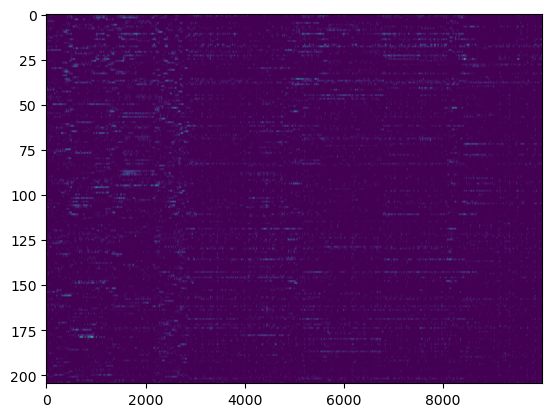

In [52]:
plt.imshow(spike_array.T , aspect='auto')

In [5]:


def get_population_rates(spikes, T, dt ,sigma_ms=50):
    """
    Converts spike dictionary to a (Time x Cells) population rate matrix.
    """
    n_bins = len(T)
    cell_ids = list(spikes.keys())
    
    population_matrix = np.zeros((n_bins, len(cell_ids))) #(Time points, Number of Cells)
    
    for i, cell in enumerate(cell_ids):
        spike_times = spikes[cell]
        
        t_start = T[0] # - dt/2
        t_end = T[-1]  # + dt/2
        edges = np.linspace(t_start, t_end, n_bins + 1)
        
        binned_spikes, _ = np.histogram(spike_times, bins=edges)
        
        # Sigma is usually ~50-100ms for grid cells 
        sigma_bins = (sigma_ms / 1000) / dt 
        smoothed_rate = gaussian_filter1d(binned_spikes.astype(float), sigma=sigma_bins)
        
        population_matrix[:, i] = smoothed_rate
        
    return population_matrix, cell_ids



In [6]:
cutoff_ind = T.shape[0]//10

In [7]:
pop_activity1, cell_ids = get_population_rates(grid_mod1, T[:cutoff_ind], dt, sigma_ms=120)
# pop_activity2, cell_ids = get_population_rates(grid_mod2, T, dt, sigma_ms=80)
# pop_activity3, cell_ids = get_population_rates(grid_mod3, T, dt, sigma_ms=80)

In [8]:

run_indices = V[:cutoff_ind] > 5
pop_activity_clean1 = pop_activity1[run_indices]
X_clean = X[:cutoff_ind][run_indices]
Y_clean = Y[:cutoff_ind][run_indices]

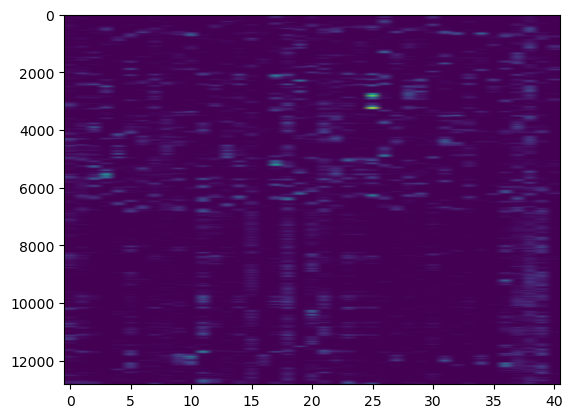

In [9]:
plt.imshow(pop_activity_clean1, aspect='auto')

In [25]:
corr_matrix = np.corrcoef(pop_activity_clean1[:3000] )#, pop_activity_clean1[:1000])

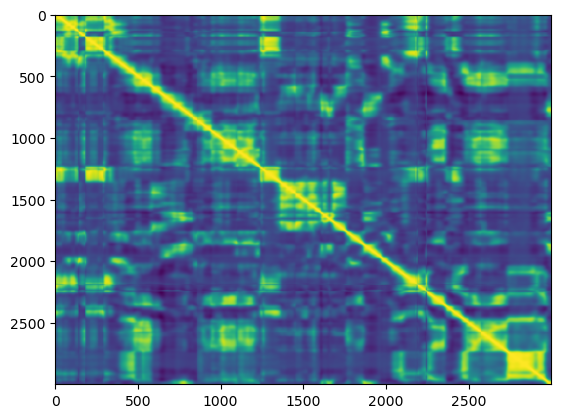

In [26]:
plt.imshow(corr_matrix , aspect='auto')

In [ ]:
# all_activity = np.hstack((pop_activity1, pop_activity2, pop_activity3))
# print(pop_activity1.shape , pop_activity2.shape , pop_activity3.shape , all_activity.shape)

(234129, 41) (234129, 74) (234129, 90) (234129, 205)


In [30]:
# Assuming pop_activity is your (Time x Cells) matrix
# Subsample: Take every 10th point (effectively 12Hz if original was 120Hz)
pop_activity_sub = pop_activity_clean1[::10, :] 
X_sub = X_clean[::10]
Y_sub = Y_clean[::10]

# Run PCA/UMAP on pop_activity_sub

In [31]:
pca = PCA(n_components=6)
pca_projection = pca.fit_transform(pop_activity_sub)

In [32]:
reducer = umap.UMAP(n_components=3, n_neighbors=200, min_dist=0.5, metric='cosine')
manifold_3d = reducer.fit_transform(pca_projection)

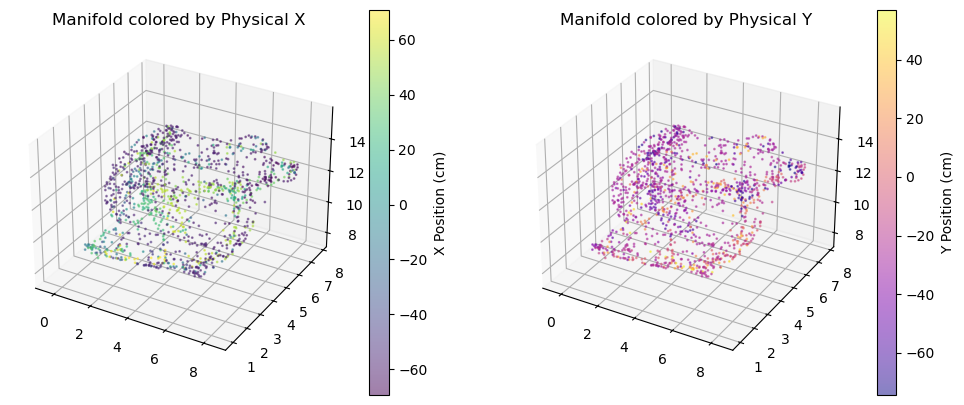

In [33]:
# Create a 3D Plot
fig = plt.figure(figsize=(12, 5))

# Subplot 1: Color by X position
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(manifold_3d[:, 0], manifold_3d[:, 1], manifold_3d[:, 2], 
                  c=X_sub, cmap='viridis', s=1, alpha=0.5)
ax1.set_title('Manifold colored by Physical X')
plt.colorbar(sc1, ax=ax1, label='X Position (cm)')

# Subplot 2: Color by Y position
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(manifold_3d[:, 0], manifold_3d[:, 1], manifold_3d[:, 2], 
                  c=Y_sub, cmap='plasma', s=1, alpha=0.5)
ax2.set_title('Manifold colored by Physical Y')
plt.colorbar(sc2, ax=ax2, label='Y Position (cm)')

plt.show()